In [1]:
import os
os.environ["DDE_BACKEND"]="pytorch"

In [2]:
import numpy as np 
import torch

In [3]:
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
def derivatives(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    d3y = torch.autograd.grad(d2y, x, grad_outputs=torch.ones_like(d2y), create_graph=True)[0]
    d4y = torch.autograd.grad(d3y, x, grad_outputs=torch.ones_like(d3y), create_graph=True)[0]
    return dy, d2y, d3y, d4y

In [5]:
def physics_loss(model, x, EI):
    x.requires_grad_(True)
    y = model(x)

    _, _, _, d4y = derivatives(y, x)

    q = -10  # UniformLoad
    loss = torch.mean((d4y - q/EI)**2)

    return loss

In [6]:
model=PINN()

x_test = torch.linspace(0, 1, 100).reshape(-1,1)
y_pred = model(x_test)

In [7]:
def boundary_loss(model, EI):
    x0 = torch.tensor([[0.0]], requires_grad=True)
    xL = torch.tensor([[1.0]], requires_grad=True)

    y0 = model(x0)
    yL = model(xL)

    _, d2y0, _, _ = derivatives(y0, x0)
    _, d2yL, _, _ = derivatives(yL, xL)

    loss = y0**2 + yL**2 + d2y0**2 + d2yL**2
    return loss
  

In [8]:
def total_loss(model, x, EI):
    return physics_loss(model, x, EI) + 1000 * boundary_loss(model, EI)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

EI = 1.0
loss_history =[]

for epoch in range(10000):
    x = torch.rand(100, 1)  

    loss = total_loss(model, x, EI)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())

0 98.81806945800781
1000 77.14865112304688
2000 45.97639083862305
3000 40.55781173706055
4000 22.582130432128906
5000 16.913557052612305
6000 8.066646575927734
7000 3.2436158657073975
8000 2.220372438430786
9000 1.0794708728790283


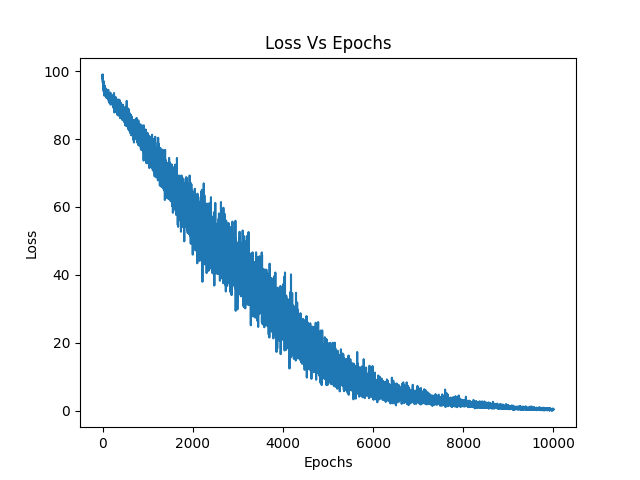

In [10]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Vs Epochs")
plt.show()

In [11]:
x_test = torch.linspace(0, 1, 100).reshape(-1,1)
x_test.requires_grad_(True)

y = model(x_test)

dy, d2y, d3y, d4y = derivatives(y, x_test)

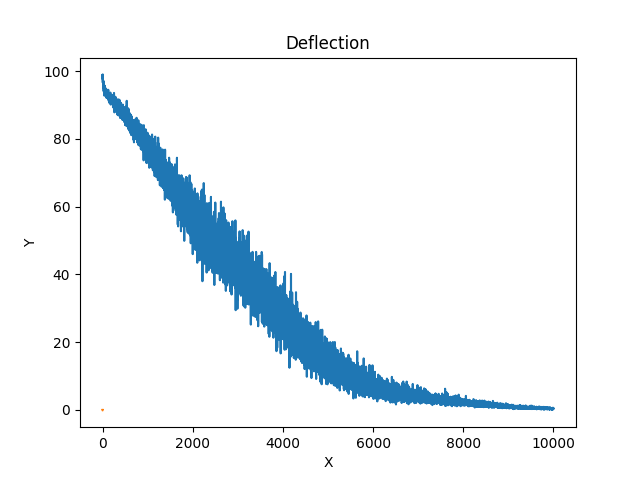

In [12]:
plt.plot(x_test.cpu().detach().numpy(), y.cpu().detach().numpy())
plt.title("Deflection")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [13]:
M= -EI * d2y

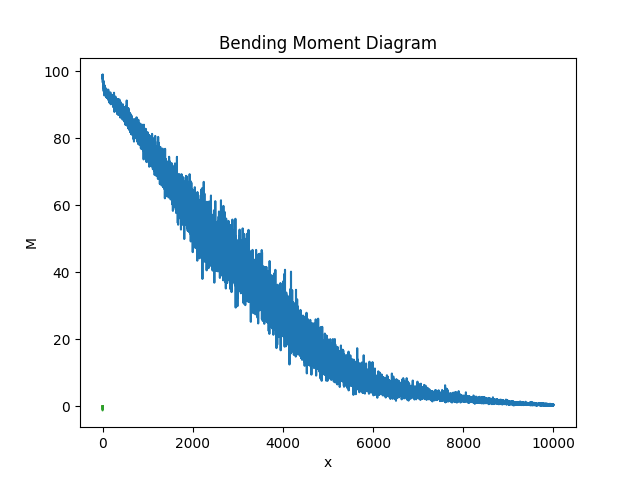

In [14]:
plt.plot(x_test.cpu().detach().numpy(), M.cpu().detach().numpy())
plt.title("Bending Moment Diagram")
plt.xlabel("x")
plt.ylabel("M")
plt.show()

## Validation against the analytical solution

For a simply supported beam of length $L$ under a uniform load $q$, the Euler-Bernoulli equation
$EI\,y'''' = q$ with $y(0)=y(L)=0$ and $y''(0)=y''(L)=0$ has the closed-form solution

$$y(x) = \frac{q}{24EI}\left(x^4 - 2Lx^3 + L^3x\right)$$

We use this to check the PINN prediction against ground truth, instead of only looking at loss curves.

In [15]:
def analytical_deflection(x, q, EI, L=1.0):
    return (q / (24 * EI)) * (x**4 - 2 * L * x**3 + L**3 * x)

x_np = x_test.cpu().detach().numpy().flatten()
y_true = analytical_deflection(x_np, q=-10, EI=EI, L=1.0)
y_pred_np = y.cpu().detach().numpy().flatten()


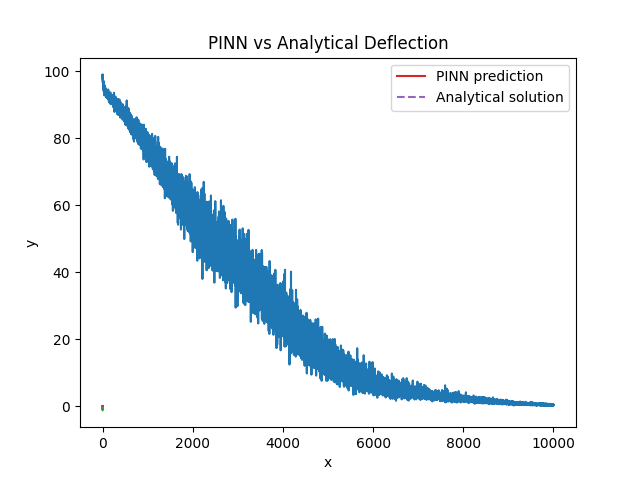

In [16]:
plt.plot(x_np, y_pred_np, label="PINN prediction")
plt.plot(x_np, y_true, '--', label="Analytical solution")
plt.title("PINN vs Analytical Deflection")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [17]:
l2_error = np.linalg.norm(y_pred_np - y_true) / np.linalg.norm(y_true)
max_abs_error = np.max(np.abs(y_pred_np - y_true))

print(f"Relative L2 error: {l2_error*100:.2f}%")
print(f"Max absolute error: {max_abs_error:.6f}")


Relative L2 error: 0.77%
Max absolute error: 0.000995
